## FACIAL ATTRBIUTES RECOGNITION

In [10]:
import os,sys,cv2, pandas as pd, numpy as np
from PIL import Image
from skimage.filters import gaussian
#-------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
#-------------------------------------------------
import shap_bpt
print('shap_bpt version:',shap_bpt.__version__)
#-------------------------------------------------

shap_bpt version: 1.0


# Download Pretrained Model weights from following link:
- Make sure to download model.pth from https://www.kaggle.com/code/kartikbatra/multilabelclassification/output?select=model.pth
- set the downloaded pretrained model path in code

In [ ]:
## PATHS SETUP and LOAD ANNOTATIONS
path_base = os.getcwd()
path_current = os.path.join(os.path.dirname(os.getcwd()), 'notebooks','E5_CelebA')   # parent folder
sys.path.append(path_base)
sys.path.append(path_current)

# import utils_facial as utf

path_train_weights = os.path.join(path_current, 'model.pth')
print("Path to trained model weights:", os.path.exists(path_train_weights))
path_dataset = r'D:\DS\CelebAMask-HQ'
csv_anno_file = f'{path_dataset}//CelebA-HQ-attribute.txt'
df_attr = pd.read_csv(csv_anno_file, delim_whitespace=True,skiprows=[0])
df_attr.replace(-1,0,inplace=True)
classes_names = df_attr.columns[1:].tolist()
classes_names_name_to_id = {name:i for i,name in enumerate(classes_names)}

Path to trained model weights: True


C:\Users\XN2\AppData\Local\Temp\ipykernel_29656\1200544884.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_attr = pd.read_csv(csv_anno_file, delim_whitespace=True,skiprows=[0])


In [ ]:
url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
with urllib.request.urlopen(url) as response:
    data = json.loads(response.read().decode())

In [12]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if ('mps' in dir(torch.backends)) and torch.backends.mps.is_available() else torch.device("cpu")
device

device(type='cuda')

In [13]:
# Defining Class for Single Layer. 
class Layer(nn.Module):
    def __init__(self,in_ch,out_ch,kernel_size=3,stride=1,padding=1):
        super(Layer,self).__init__()
        self.conv=nn.Conv2d(in_ch,out_ch,kernel_size,stride,padding)
        self.bn=nn.BatchNorm2d(out_ch)
        self.relu=nn.ReLU()
        nn.init.xavier_uniform_(self.conv.weight)
    def forward(self,Input):
        output=self.conv(Input)
        output=self.bn(output)
        output=self.relu(output)
        return output
    


# Complete model
class CelebModel(nn.Module):
    def __init__(self,num_classes=40):
        super(CelebModel,self).__init__()
        
        self.unit1=Layer(in_ch=3,out_ch=32)        
        self.unit2=Layer(in_ch=32,out_ch=32)
        self.pool1=nn.MaxPool2d(kernel_size=2)
        
        self.unit3=Layer(in_ch=32,out_ch=64)
        self.unit4=Layer(in_ch=64,out_ch=64)
        self.pool2=nn.MaxPool2d(kernel_size=2)
        
        self.unit5=Layer(in_ch=64,out_ch=128)
        self.unit6=Layer(in_ch=128,out_ch=128)
        self.unit7=Layer(in_ch=128,out_ch=128)
        self.pool3=nn.MaxPool2d(kernel_size=2)
        
        self.unit8=Layer(in_ch=128,out_ch=256,kernel_size=5,padding=0)
        self.unit9=Layer(in_ch=256,out_ch=256,kernel_size=5,padding=0)
        self.unit10=Layer(in_ch=256,out_ch=256,kernel_size=5,padding=0)
        self.pool4=nn.MaxPool2d(kernel_size=2)
        
        self.drop2=nn.Dropout(0.5)   
        
        self.unit11=Layer(in_ch=256,out_ch=512,kernel_size=3,padding=0)
        self.unit12=Layer(in_ch=512,out_ch=512,kernel_size=3,padding=0)
        self.unit13=Layer(in_ch=512,out_ch=512,kernel_size=3,padding=0)
        
        self.pool5=nn.AvgPool2d(kernel_size=2)
        
        self.drop3=nn.Dropout(0.5)
        
        self.model=nn.Sequential(self.unit1,self.unit2,self.pool1,self.unit3,
                                 self.unit4,self.pool2,self.unit5,self.unit6,
                                 self.unit7,self.pool3,self.unit8,self.unit9,
                                 self.unit10,self.pool4,self.drop2,self.unit11,
                                 self.unit12,self.unit13,self.pool5,self.drop3)
        
        self.fc=nn.Linear(in_features=512,out_features=num_classes)
        
    def forward(self,Input):
        
        output=self.model(Input)
        output=output.view(-1,512)
        output=self.fc(output)
        
        return output

In [14]:
model=CelebModel().to(device)
model.load_state_dict(torch.load(path_train_weights,map_location=device))
model = model.eval()

## Masking Function

In [15]:
valid_transform=transforms.Compose([transforms.Resize((224,224)),
                                    transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.5063, 0.4258, 0.3832],std=[0.2644, 0.2436, 0.2397])])
def load_image(img_filename,bg_type='blurred'):
    global image_to_explain_tensor
   #-----------------------------------------------------------------------------
    image_to_explain       = cv2.resize(cv2.imread(img_filename, cv2.IMREAD_COLOR),[224,224])[:,:,::-1]
    #-----------------------------------------------------------------------------
    image_to_explain_preproc  = valid_transform(Image.fromarray(image_to_explain))
    image_to_explain_tensor = image_to_explain_preproc.to(device)
    #-----------------------------------------------------------------------------
    bkgnd0 = np.full_like(image_to_explain, 0)
    bkgnd1 = np.full_like(image_to_explain, 127)
    bkgnd2 = np.full_like(image_to_explain, 255)
    bkgnd3 = gaussian(image_to_explain, 8, channel_axis=-1)*255
    bkgnd4 = np.clip(np.random.normal(128, 128, size=image_to_explain.shape), 0, 255).astype(np.uint8)
    bkgnd4 = (gaussian(bkgnd4, 2.0, channel_axis=-1) * 255).astype(np.uint8)
    if bg_type=='black':        background_image_set = np.array([bkgnd0])
    elif bg_type=='gray':       background_image_set = np.array([bkgnd1])
    elif bg_type=='white':      background_image_set = np.array([bkgnd2])
    elif bg_type=='blurred':    background_image_set = np.array([bkgnd3])
    elif bg_type=='noise':      background_image_set = np.array([bkgnd4])
    elif bg_type=='full':       background_image_set = np.array([bkgnd0, bkgnd1, bkgnd2, bkgnd3, bkgnd4])
    else:                        raise ValueError(f"Unknown bg_type:{bg_type}")
    #-----------------------------------------------------------------------------
    background_image_preproc_set = [valid_transform(Image.fromarray(bkgnd.astype(np.uint8)))
                                        for bkgnd in background_image_set]
    background_tensors = torch.cat([torch.unsqueeze(bk_p, dim=0) 
                                    for bk_p in background_image_preproc_set]).to(device)
    return image_to_explain,image_to_explain_preproc,image_to_explain_tensor,background_image_set,background_tensors

In [16]:
def load_image_to_explain(intrested_class,img_filename=None,bg_type='blurred'):
    image_to_explain,image_to_explain_preproc,image_to_explain_tensor,background_image_set,background_tensors = load_image(img_filename=img_filename,bg_type=bg_type)
    h,w,_ = image_to_explain.shape
    # Foreground image to be explained   
    predicted_fS = f(image_to_explain_tensor.unsqueeze(0))[0]
    sorted_classes = np.flip(np.argsort(predicted_fS))
    #-----------------------------------------------------------------------------
    predicted_cls = sorted_classes[0]
    f_S = float(predicted_fS[intrested_class])
    #-----------------------------------------------------------------------------
    predicted_f0 = [f(bkgnd.unsqueeze(0))[0] for bkgnd in background_tensors]
    predicted_f0 = np.mean(predicted_f0,axis=0)
    f_0          = float(predicted_f0[intrested_class])
    return image_to_explain,image_to_explain_preproc,image_to_explain_tensor,background_image_set,background_tensors,f_S,f_0,predicted_cls

In [17]:
### MASKING FUNCTIONS
def f_masked_resnet(masks):
    global f, background_tensors, image_to_explain_tensor
    N,H,W = masks.shape
    B = background_tensors.shape[0]
    masks_tensor = torch.tensor(np.array(masks)).to(device)                     # N boolean masks with size W*H
    masks_tensor = torch.reshape(masks_tensor, (N,1,H,W))                       # N*H*W    -> N*1*H*W
    masks_tensor = torch.tile(masks_tensor, dims=(1,3,B,1)).reshape(B*N,3,H,W)  # N*1*H*W  -> NB*3*H*W
    Xf = torch.tile(image_to_explain_tensor, dims=(N*B,1,1,1))                  # 3*H*W    -> NB*3*H*W
    Xb = torch.tile(background_tensors, dims=(N,1,1,1))                         # 3*H*W    -> NB*3*H*W
    X = torch.where(masks_tensor, Xf, Xb) # T=Xf, F=Xb
    result = f(X)
    del X, Xb, Xf, masks_tensor
    result = result.reshape((-1, B, result.shape[1]))
    return np.mean(result, axis=1)

def f_masked(masks):
    return np.expand_dims(f_masked_resnet(masks)[:,intrested_class], axis =-1)

def f(x):
    return model(x).cpu().detach().numpy()


In [18]:
intrested_class = classes_names_name_to_id['Brown_Hair']
# intrested_class = classes_names_name_to_id['Smiling']
#-----------------------------------------------------------------------------
img_id = 0
image_to_explain,_,_,\
    background_image_set,background_tensors,f_S,f_0,predicted_cls = load_image_to_explain(img_filename = rf'D:\DS\CelebAMask-HQ\CelebA-HQ-img\{img_id}.jpg', intrested_class=intrested_class)
print('Explained class:', classes_names[intrested_class])

Explained class: Brown_Hair


In [19]:
#-----------------------------------------------------------------------------
num_samples = 100
bpt = shap_bpt.build_bpt_from_image((image_to_explain))
#-----------------------------------------------------------------------------
explainer = shap_bpt.Explainer(f_masked, image_to_explain,num_explained_classes=4,verbose=True)
#-----------------------------------------------------------------------------
print(f'Model Confidence: {explainer.base_f_S[0]-explainer.base_f_0[0]:0.5}')
shap_values_bpt = explainer.explain_instance(num_samples,method='BPT',batch_size=8,bpt=bpt)
shap_values_aa = explainer.explain_instance(num_samples,method='AA',batch_size=8,bpt=bpt)


Model Confidence: 3.8438


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

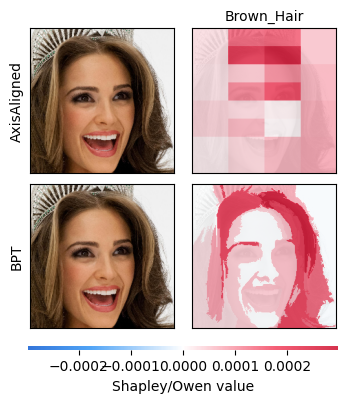

In [20]:
## PLOT OWEN VALUES
# shap_bpt.plot_owen_values(explainer, [shap_values_aa],[classes_names[i] for i in [intrested_class]], names=['AxisAligned'])
# shap_bpt.plot_owen_values(explainer, [shap_values_bpt],[classes_names[i] for i in [intrested_class]], names=['BPT'])
shap_bpt.plot_owen_values(explainer, [shap_values_aa,shap_values_bpt],[classes_names[i] for i in [intrested_class]], names=['AxisAligned','BPT'])